# Competition Model Training Notebook

This notebook version mirrors `train_competition_models.py`, but keeps the work visible cell by cell: data checks, feature selection, grouped validation, Optuna tuning, early stopping, reports, and saving model artifacts.

The main knobs are in the first code cell. Increase `LGBM_TRIALS`, `N_ESTIMATORS_MAX`, and `EARLY_STOPPING_ROUNDS` when you want a stronger but slower search.

## Why This Setup

- `crop_type` is trained from all point/image rows because crop type is stable per point.
- `phenophase_name` is trained from the original `points_train_label.csv`, then each label row receives the closest satellite feature row.
- `nearest_phenophase_name` and original phenophase date columns are treated as leakage and removed from model inputs.
- Validation uses `GroupKFold(point_id)` so the same location cannot appear in both train and validation.

In [1]:
from pathlib import Path

ROOT = Path.cwd()
FEATURES_CSV = ROOT / "features_all_images_with_labels.csv"
LABELS_CSV = ROOT / "points_train_label.csv"
OUTPUT_DIR = ROOT / "training_outputs_notebook"
OUTPUT_DIR.mkdir(exist_ok=True)

# Validation / optimizer controls
FOLDS = 5
LGBM_TRIALS = 75          # increase to 50-150 for a longer search
EARLY_STOPPING_ROUNDS = 100
N_ESTIMATORS_MIN = 300
N_ESTIMATORS_MAX = 5000   # early stopping lets this be high
MISSING_THRESHOLD = 0.65
RANDOM_STATE = 42

# Choose whether final LightGBM uses the median best_iteration from CV.
USE_CV_BEST_ITERATION_FOR_FINAL = True

print(ROOT)

c:\File Reno\Programming\GMAT\Real GMAT\AIG\Final\Code\Coba\renov2


In [2]:
import json
import warnings

import joblib
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import seaborn as sns
from sklearn.base import clone
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.model_selection import GroupKFold
from sklearn.pipeline import Pipeline

import train_competition_models as tcm

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message="X does not have valid feature names.*")
optuna.logging.set_verbosity(optuna.logging.WARNING)
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)

In [3]:
# Load source data and build the two supervised datasets.
features = pd.read_csv(FEATURES_CSV)
labels = pd.read_csv(LABELS_CSV)

features = tcm.normalize_dates(features, ["image_date"])
labels = tcm.normalize_dates(labels, ["phenophase_date"])
features = features.rename(columns={"image_date": "image_date_dt"})
features["image_date"] = features["image_date_dt"].dt.strftime("%Y-%m-%d")
labels = labels.rename(columns={"phenophase_date": "phenophase_date_dt"})

point_agg = tcm.add_point_time_series_aggregates(features)
crop_df = tcm.build_crop_dataset(features, point_agg)
phase_df = tcm.build_phenophase_dataset(features, labels, point_agg)

print("features:", features.shape)
print("labels:", labels.shape)
print("crop_df:", crop_df.shape)
print("phase_df:", phase_df.shape)
display(crop_df.head(3))
display(phase_df.head(3))

features: (12719, 46)
labels: (5446, 6)
crop_df: (12719, 171)
phase_df: (5348, 222)


,point_id,Longitude,Latitude,crop_type,region,matched_region_count,image_date_dt,image_year,image_month,image_doy,nearest_phenophase_name,nearest_phenophase_date,days_from_nearest_phenophase,abs_days_to_nearest_phenophase,Greenup_date,MidGreenup_date,Peak_date,Maturity_date,Senescence_date,MidSenescence_date,Dormancy_date,B_B01,B_B02,B_B03,B_B04,B_B05,B_B06,B_B07,B_B08,B_B8A,B_B09,B_B10,B_B11,B_B12,valid_band_count,NDVI,SAVI,GNDVI,NDMI,NDBI,MNDWI,EVI,RENDVI_B05,NDRE_B8A,NBR2,image_date,lon_lat_product,lon_sq,lat_sq,image_doy_sin,image_doy_cos,image_month_sin,image_month_cos,ts_B_B01_mean,ts_B_B01_std,ts_B_B01_min,ts_B_B01_max,ts_B_B02_mean,ts_B_B02_std,ts_B_B02_min,...,ts_MNDWI_min,ts_MNDWI_max,ts_NBR2_mean,ts_NBR2_std,ts_NBR2_min,ts_NBR2_max,ts_NDBI_mean,ts_NDBI_std,ts_NDBI_min,ts_NDBI_max,ts_NDMI_mean,ts_NDMI_std,ts_NDMI_min,ts_NDMI_max,ts_NDRE_B8A_mean,ts_NDRE_B8A_std,ts_NDRE_B8A_min,ts_NDRE_B8A_max,ts_NDVI_mean,ts_NDVI_std,ts_NDVI_min,ts_NDVI_max,ts_RENDVI_B05_mean,ts_RENDVI_B05_std,ts_RENDVI_B05_min,ts_RENDVI_B05_max,ts_SAVI_mean,ts_SAVI_std,ts_SAVI_min,ts_SAVI_max,ts_valid_band_count_mean,ts_valid_band_count_std,ts_valid_band_count_min,ts_valid_band_count_max,ts_B_B01_range,ts_B_B02_range,ts_B_B03_range,ts_B_B04_range,ts_B_B05_range,ts_B_B06_range,ts_B_B07_range,ts_B_B08_range,ts_B_B09_range,ts_B_B11_range,ts_B_B12_range,ts_B_B8A_range,ts_EVI_range,ts_GNDVI_range,ts_MNDWI_range,ts_NBR2_range,ts_NDBI_range,ts_NDMI_range,ts_NDRE_B8A_range,ts_NDVI_range,ts_RENDVI_B05_range,ts_SAVI_range,ts_valid_band_count_range,ts_NDVI_peak_doy,ts_NDVI_peak_month,ts_NDVI_peak_value
0,1,125.52644,49.339533,soybean,region09,1,2018-04-09,2018,4,99,Greenup,2018-06-07,-59.0,59.0,2018-06-07,2018-06-30,2018-08-06,2018-07-22,2018-08-21,2018-09-12,2018-10-03,0.0599,0.0616,0.0652,0.0773,0.1091,0.1143,0.1340,0.1306,0.1422,0.1287,NaN,0.2105,0.1812,12,0.256373,0.112940,0.334014,-0.234242,0.234242,-0.527022,0.117670,0.170601,0.295672,0.074802,2018-04-09,6193.41596,15756.887089,2434.389549,0.991723,-0.128398,0.866025,-0.500000,2.10108,7.994664,0.0194,31.0,1.566007,5.929562,0.0198,...,-0.698392,-0.4,0.243696,0.121363,0.070318,0.411119,-0.053253,0.231878,-0.340678,0.26587,0.053253,0.231878,-0.26587,0.340678,0.669622,0.230431,0.295672,0.914251,0.626625,0.246655,0.248419,0.90228,0.357555,0.155019,0.136961,0.55443,0.389082,0.229594,0.11294,0.854305,12.266667,0.457738,12,13,30.9806,22.9802,20.9674,15.9824,24.9386,55.8857,65.8781,58.8934,13.8767,48.8505,27.9293,74.8578,7.219219,0.489764,0.298392,0.340801,0.606548,0.606548,0.618579,0.653861,0.41747,0.741365,1,227,8,0.90228
1,1,125.52644,49.339533,soybean,region09,1,2018-04-24,2018,4,114,Greenup,2018-06-07,-44.0,44.0,2018-06-07,2018-06-30,2018-08-06,2018-07-22,2018-08-21,2018-09-12,2018-10-03,0.0624,0.0540,0.0684,0.0832,0.1115,0.1275,0.1316,0.1382,0.1653,0.1457,NaN,0.2383,0.2022,12,0.248419,0.114361,0.337851,-0.265870,0.265870,-0.553962,0.111571,0.145352,0.330382,0.081952,2018-04-24,6193.41596,15756.887089,2434.389549,0.926324,-0.376728,0.866025,-0.500000,2.10108,7.994664,0.0194,31.0,1.566007,5.929562,0.0198,...,-0.698392,-0.4,0.243696,0.121363,0.070318,0.411119,-0.053253,0.231878,-0.340678,0.26587,0.053253,0.231878,-0.26587,0.340678,0.669622,0.230431,0.295672,0.914251,0.626625,0.246655,0.248419,0.90228,0.357555,0.155019,0.136961,0.55443,0.389082,0.229594,0.11294,0.854305,12.266667,0.457738,12,13,30.9806,22.9802,20.9674,15.9824,24.9386,55.8857,65.8781,58.8934,13.8767,48.8505,27.9293,74.8578,7.219219,0.489764,0.298392,0.340801,0.606548,0.606548,0.618579,0.653861,0.41747,0.741365,1,227,8,0.90228
2,1,125.52644,49.339533,soybean,region09,1,2018-05-09,2018,5,129,Greenup,2018-06-07,-29.0,29.0,2018-06-07,2018-06-30,2018-08-06,2018-07-22,2018-08-21,2018-09-12,2018-10-03,0.0674,0.0704,0.0767,0.0920,0.1212,0.1390,0.1633,0.1622,0.1726,0.1658,NaN,0.2443,0.2122,12,0.276161,0.139618,0.357890,-0.201968,0.201968,-0.522118,0.147951,0.136961,0.304611,0.070318,2018-05-09,6193.41596,15756.887089,2434.389549,0.799839,-0.600214,0.5000

,point_id,Longitude,Latitude,region,matched_region_count,image_date,image_year,image_month,image_doy,label_year,label_month,label_doy,days_to_image,abs_days_to_image,crop_type,phenophase_name,B_B01,B_B02,B_B03,B_B04,B_B05,B_B06,B_B07,B_B08,B_B09,B_B11,B_B12,B_B8A,EVI,GNDVI,MNDWI,NBR2,NDBI,NDMI,NDRE_B8A,NDVI,RENDVI_B05,SAVI,valid_band_count,prev_days_to_label,prev_B_B01,prev_B_B02,prev_B_B03,prev_B_B04,prev_B_B05,prev_B_B06,prev_B_B07,prev_B_B08,prev_B_B09,prev_B_B11,prev_B_B12,prev_B_B8A,prev_EVI,prev_GNDVI,prev_MNDWI,prev_NBR2,prev_NDBI,prev_NDMI,prev_NDRE_B8A,prev_NDVI,...,ts_MNDWI_min,ts_MNDWI_max,ts_NBR2_mean,ts_NBR2_std,ts_NBR2_min,ts_NBR2_max,ts_NDBI_mean,ts_NDBI_std,ts_NDBI_min,ts_NDBI_max,ts_NDMI_mean,ts_NDMI_std,ts_NDMI_min,ts_NDMI_max,ts_NDRE_B8A_mean,ts_NDRE_B8A_std,ts_NDRE_B8A_min,ts_NDRE_B8A_max,ts_NDVI_mean,ts_NDVI_std,ts_NDVI_min,ts_NDVI_max,ts_RENDVI_B05_mean,ts_RENDVI_B05_std,ts_RENDVI_B05_min,ts_RENDVI_B05_max,ts_SAVI_mean,ts_SAVI_std,ts_SAVI_min,ts_SAVI_max,ts_valid_band_count_mean,ts_valid_band_count_std,ts_valid_band_count_min,ts_valid_band_count_max,ts_B_B01_range,ts_B_B02_range,ts_B_B03_range,ts_B_B04_range,ts_B_B05_range,ts_B_B06_range,ts_B_B07_range,ts_B_B08_range,ts_B_B09_range,ts_B_B11_range,ts_B_B12_range,ts_B_B8A_range,ts_EVI_range,ts_GNDVI_range,ts_MNDWI_range,ts_NBR2_range,ts_NDBI_range,ts_NDMI_range,ts_NDRE_B8A_range,ts_NDVI_range,ts_RENDVI_B05_range,ts_SAVI_range,ts_valid_band_count_range,ts_NDVI_peak_doy,ts_NDVI_peak_month,ts_NDVI_peak_value
0,1,125.52644,49.339533,region09,1,2018-05-29,2018,5,149,2018,6,158,-9,9,soybean,Greenup,0.0645,0.0611,0.0760,0.0741,0.1160,0.1819,0.2243,0.2172,0.1924,0.2362,0.1908,0.2192,0.297246,0.481583,-0.513133,0.106323,0.041906,-0.041906,0.494715,0.491246,0.220410,0.271262,12,-9,0.0645,0.0611,0.0760,0.0741,0.1160,0.1819,0.2243,0.2172,0.1924,0.2362,0.1908,0.2192,0.297246,0.481583,-0.513133,0.106323,0.041906,-0.041906,0.494715,0.491246,...,-0.698392,-0.4,0.243696,0.121363,0.070318,0.411119,-0.053253,0.231878,-0.340678,0.26587,0.053253,0.231878,-0.26587,0.340678,0.669622,0.230431,0.295672,0.914251,0.626625,0.246655,0.248419,0.90228,0.357555,0.155019,0.136961,0.55443,0.389082,0.229594,0.11294,0.854305,12.266667,0.457738,12,13,30.9806,22.9802,20.9674,15.9824,24.9386,55.8857,65.8781,58.8934,13.8767,48.8505,27.9293,74.8578,7.219219,0.489764,0.298392,0.340801,0.606548,0.606548,0.618579,0.653861,0.41747,0.741365,1,227,8,0.90228
1,1,125.52644,49.339533,region09,1,2018-06-28,2018,6,179,2018,6,181,-2,2,soybean,MidGreenup,31.0000,23.0000,21.0000,16.0000,25.0000,56.0000,66.0000,59.0000,14.0000,49.0000,28.0000,75.0000,-6.515152,0.475000,-0.400000,0.272727,-0.092593,0.092593,0.648352,0.573333,0.219512,0.854305,13,-2,31.0000,23.0000,21.0000,16.0000,25.0000,56.0000,66.0000,59.0000,14.0000,49.0000,28.0000,75.0000,-6.515152,0.475000,-0.400000,0.272727,-0.092593,0.092593,0.648352,0.573333,...,-0.698392,-0.4,0.243696,0.121363,0.070318,0.411119,-0.053253,0.231878,-0.340678,0.26587,0.053253,0.231878,-0.26587,0.340678,0.669622,0.230431,0.295672,0.914251,0.626625,0.246655,0.248419,0.90228,0.357555,0.155019,0.136961,0.55443,0.389082,0.229594,0.11294,0.854305,12.266667,0.457738,12,13,30.9806,22.9802,20.9674,15.9824,24.9386,55.8857,65.8781,58.8934,13.8767,48.8505,27.9293,74.8578,7.219219,0.489764,0.298392,0.340801,0.606548,0.606548,0.618579,0.653861,0.41747,0.741365,1,227,8,0.90228
2,1,125.52644,49.339533,region09,1,2018-07-31,2018,7,212,2018,8,218,-6,6,soybean,Peak,0.0262,0.0268,0.0456,0.0236,0.0723,0.3419,0.4484,0.4016,0.5686,0.1975,0.0924,0.4653,0.704068,0.796064,-0.624846,0.362539,-0.340678,0.340678,0.903457,0.888993,0.507821,0.612840,13,-6,0.0262,0.0268,0.0456,0.0236,0.0723,0.3419,0.4484,0.4016,0.5686,0.1975,0.0924,0.4653,0.704068,0.796064,-0.624846,0.362539,-0.340678,0.340678,0.903457,0.888993,...,-0.698392,-0.4,0.243696,0.121363,0.070318,0.411119,-0.053253,0.231878,-0.340678,0.26587,0.053253,0.231878,-0.26587,0.340678,0.669622,0.230431,0.295672,0.914251,0.626625,0.246655,0.248419,0.9022

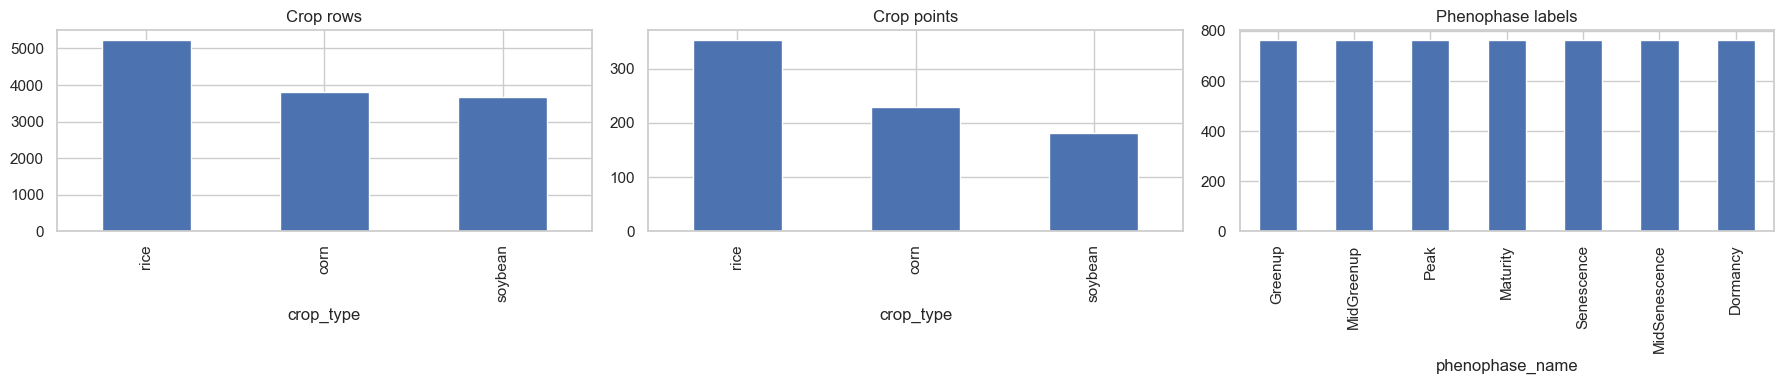

,crop_rows,crop_points
crop_type,,
rice,5231,353
corn,3812,229
soybean,3676,182


,count
phenophase_name,
Greenup,764
MidGreenup,764
Peak,764
Maturity,764
Senescence,764
MidSenescence,764
Dormancy,764


,abs_days_to_image
count,5348.000000
mean,8.137061
std,18.043868
min,0.000000
25%,2.000000
50%,4.000000
75%,7.000000
max,157.000000


In [4]:
# Distribution checks.
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
crop_df["crop_type"].value_counts().plot(kind="bar", ax=axes[0], title="Crop rows")
crop_df.drop_duplicates("point_id")["crop_type"].value_counts().plot(kind="bar", ax=axes[1], title="Crop points")
phase_df["phenophase_name"].value_counts().reindex(tcm.PHASES).plot(kind="bar", ax=axes[2], title="Phenophase labels")
plt.tight_layout()
plt.show()

display(pd.DataFrame({
    "crop_rows": crop_df["crop_type"].value_counts(),
    "crop_points": crop_df.drop_duplicates("point_id")["crop_type"].value_counts()
}))
display(phase_df["phenophase_name"].value_counts().reindex(tcm.PHASES).to_frame("count"))
display(phase_df["abs_days_to_image"].describe().to_frame("abs_days_to_image"))

In [5]:
# Feature selection: remove leakage and high-missing columns.
crop_features, crop_cat, crop_num, crop_dropped = tcm.select_features(
    crop_df,
    target="crop_type",
    missing_threshold=MISSING_THRESHOLD,
    force_drop={"phenophase_name"},
)
phase_features, phase_cat, phase_num, phase_dropped = tcm.select_features(
    phase_df,
    target="phenophase_name",
    missing_threshold=MISSING_THRESHOLD,
    force_drop={"crop_type"},
)

crop_bundle = tcm.DatasetBundle("crop_type", crop_df, "crop_type", crop_df["point_id"], crop_features, crop_cat, crop_num)
phase_bundle = tcm.DatasetBundle("phenophase_name", phase_df, "phenophase_name", phase_df["point_id"], phase_features, phase_cat, phase_num)

print("Crop features:", len(crop_features), "categorical:", crop_cat)
print("Phenophase features:", len(phase_features), "categorical:", phase_cat)
print("Dropped for missing:", {"crop": crop_dropped, "phenophase": phase_dropped})

Crop features: 154 categorical: ['region']
Phenophase features: 216 categorical: ['region']
Dropped for missing: {'crop': [], 'phenophase': []}


In [6]:
# Baseline models without Optuna. Useful sanity check before long tuning.
crop_et = tcm.extra_trees_model(crop_df["crop_type"].nunique())
phase_et = tcm.extra_trees_model(phase_df["phenophase_name"].nunique())

crop_et_cv = tcm.cv_score_pipeline(crop_bundle, crop_et, "extra_trees", FOLDS)
phase_et_cv = tcm.cv_score_pipeline(phase_bundle, phase_et, "extra_trees", FOLDS)

print("Crop ExtraTrees macro-F1:", crop_et_cv["mean_f1"], crop_et_cv["fold_scores"])
print("Phenophase ExtraTrees macro-F1:", phase_et_cv["mean_f1"], phase_et_cv["fold_scores"])

Crop ExtraTrees macro-F1: 0.985495376815177 [0.9893428312032965, 0.9781713482205632, 0.9840869638069937, 0.9893888586527151, 0.9864868821923164]
Phenophase ExtraTrees macro-F1: 0.9925112442212066 [0.9944006421073391, 0.9962650730154908, 0.9943851512107954, 0.9897347366161713, 0.9877706181562365]


In [7]:
def cv_lgbm_early_stopping(dataset, params, folds=FOLDS, early_stopping_rounds=EARLY_STOPPING_ROUNDS):
    X = dataset.frame[dataset.feature_cols]
    y_encoded, encoder = tcm.encode_target(dataset.frame[dataset.target])
    groups = dataset.groups
    splitter = GroupKFold(n_splits=folds)
    n_classes = dataset.frame[dataset.target].nunique()
    fold_scores = []
    best_iterations = []
    oof_pred = np.zeros_like(y_encoded)

    for fold, (train_idx, valid_idx) in enumerate(splitter.split(X, y_encoded, groups), start=1):
        prep = tcm.make_preprocessor(dataset.numeric_cols, dataset.categorical_cols)
        X_train = prep.fit_transform(X.iloc[train_idx])
        X_valid = prep.transform(X.iloc[valid_idx])
        y_train = y_encoded[train_idx]
        y_valid = y_encoded[valid_idx]

        model = tcm.lgbm_from_params(params, n_classes)
        model.fit(
            X_train,
            y_train,
            eval_set=[(X_valid, y_valid)],
            eval_metric="multi_logloss",
            callbacks=[
                lgb.early_stopping(early_stopping_rounds, verbose=False),
                lgb.log_evaluation(0),
            ],
        )
        pred = model.predict(X_valid)
        oof_pred[valid_idx] = pred
        fold_scores.append(f1_score(y_valid, pred, average="macro"))
        best_iterations.append(int(model.best_iteration_ or params.get("n_estimators", 0)))

    report = classification_report(
        encoder.inverse_transform(y_encoded),
        encoder.inverse_transform(oof_pred),
        output_dict=True,
        zero_division=0,
    )
    conf = pd.DataFrame(
        confusion_matrix(y_encoded, oof_pred),
        index=encoder.classes_,
        columns=encoder.classes_,
    )
    return {
        "mean_f1": float(np.mean(fold_scores)),
        "std_f1": float(np.std(fold_scores)),
        "fold_scores": [float(v) for v in fold_scores],
        "best_iterations": best_iterations,
        "encoder": encoder,
        "oof_pred": oof_pred,
        "report": report,
        "confusion": conf,
    }


def suggest_lgbm_params(trial):
    return {
        "n_estimators": trial.suggest_int("n_estimators", N_ESTIMATORS_MIN, N_ESTIMATORS_MAX),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.16, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 15, 127),
        "max_depth": trial.suggest_int("max_depth", 3, 14),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 100),
        "subsample": trial.suggest_float("subsample", 0.60, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.50, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-5, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-5, 20.0, log=True),
    }


def tune_lgbm_with_early_stopping(dataset, trials=LGBM_TRIALS):
    history = []

    def objective(trial):
        params = suggest_lgbm_params(trial)
        result = cv_lgbm_early_stopping(dataset, params)
        history.append({
            "trial": trial.number,
            "mean_f1": result["mean_f1"],
            "std_f1": result["std_f1"],
            "best_iterations": result["best_iterations"],
            **params,
        })
        return result["mean_f1"]

    study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
    study.optimize(objective, n_trials=trials, show_progress_bar=True)
    best_result = cv_lgbm_early_stopping(dataset, study.best_params)
    return study, best_result, pd.DataFrame(history).sort_values("mean_f1", ascending=False)

In [8]:
# Tune crop_type LightGBM with early stopping.
crop_lgbm_study, crop_lgbm_cv, crop_lgbm_history = tune_lgbm_with_early_stopping(crop_bundle, LGBM_TRIALS)
display(crop_lgbm_history.head(10))
print("Best crop LightGBM macro-F1:", crop_lgbm_cv["mean_f1"], crop_lgbm_cv["fold_scores"])
print("Best iterations:", crop_lgbm_cv["best_iterations"])
crop_lgbm_cv["confusion"]

  0%|          | 0/75 [00:00<?, ?it/s]

,trial,mean_f1,std_f1,best_iterations,n_estimators,learning_rate,num_leaves,max_depth,min_child_samples,subsample,colsample_bytree,reg_alpha,reg_lambda
24,24,0.985895,0.011239,"[79, 66, 97, 57, 103]",407,0.056574,43,10,92,0.959386,0.846668,0.000841,0.000293
23,23,0.985622,0.011685,"[108, 82, 119, 76, 139]",435,0.043800,60,11,89,0.950020,0.844642,0.002123,0.000051
26,26,0.985622,0.011685,"[41, 36, 52, 27, 46]",730,0.112585,58,9,71,0.908835,0.936398,0.015473,0.000044
35,35,0.985622,0.011685,"[113, 85, 125, 77, 160]",2111,0.042670,58,8,84,0.780970,0.866872,0.001599,0.000028
74,74,0.985622,0.011685,"[130, 105, 152, 92, 202]",504,0.035127,59,9,79,0.804106,0.797782,0.003673,0.000047
70,70,0.985622,0.011685,"[108, 96, 134, 83, 151]",3778,0.039798,61,10,85,0.824600,0.865680,0.035913,0.000210
57,57,0.984908,0.012060,"[44, 39, 47, 30, 62]",2965,0.100208,76,11,92,0.605647,0.951778,0.005241,0.000206
53,53,0.984908,0.012060,"[45, 41, 58, 32, 60]",2386,0.097357,73,11,96,0.755710,0.961233,0.007496,0.000019
64,64,0.984908,0.012060,"[30, 26, 41, 28, 48]",800,0.123016,81,10,89,0.602537,0.950648,0.002525,0.000020
54,54,0.984908,0.012060,"[43, 40, 51, 32, 63]",977,0.097430,72,11,96,0.788527,0.961890,0.007943,0.000017


Best crop LightGBM macro-F1: 0.9858947810869443 [0.9924244860124415, 0.9676672843737534, 0.9935487691109434, 0.9781724247282556, 0.9976609412093284]
Best iterations: [79, 66, 97, 57, 103]


,corn,rice,soybean
corn,3701,61,50
rice,6,5225,0
soybean,50,0,3626


In [9]:
# Tune phenophase_name LightGBM with early stopping.
phase_lgbm_study, phase_lgbm_cv, phase_lgbm_history = tune_lgbm_with_early_stopping(phase_bundle, LGBM_TRIALS)
display(phase_lgbm_history.head(10))
print("Best phenophase LightGBM macro-F1:", phase_lgbm_cv["mean_f1"], phase_lgbm_cv["fold_scores"])
print("Best iterations:", phase_lgbm_cv["best_iterations"])
phase_lgbm_cv["confusion"]

  0%|          | 0/75 [00:00<?, ?it/s]

,trial,mean_f1,std_f1,best_iterations,n_estimators,learning_rate,num_leaves,max_depth,min_child_samples,subsample,colsample_bytree,reg_alpha,reg_lambda
40,40,0.995705,0.002675,"[52, 47, 57, 36, 54]",2427,0.158987,69,3,70,0.704274,0.966192,0.000015,0.000021
51,51,0.995704,0.002742,"[80, 82, 86, 64, 84]",3072,0.101330,68,3,70,0.675741,0.962374,0.000025,0.000020
42,42,0.995704,0.002253,"[76, 55, 81, 65, 80]",2905,0.107709,68,3,71,0.679849,0.968649,0.000016,0.000014
41,41,0.995520,0.003607,"[42, 48, 52, 38, 68]",3010,0.158087,71,3,70,0.676217,0.964628,0.000017,0.000024
44,44,0.995519,0.003143,"[116, 87, 104, 83, 123]",3039,0.079647,78,3,71,0.667723,0.967855,0.000020,0.000248
64,64,0.995519,0.003143,"[200, 222, 215, 190, 266]",2647,0.038921,84,3,62,0.660894,0.934008,0.000016,0.000840
67,67,0.995518,0.003087,"[311, 255, 306, 257, 359]",2176,0.027153,66,3,81,0.759664,0.997064,0.000079,0.000352
71,71,0.995518,0.003087,"[287, 282, 294, 239, 397]",2653,0.026862,81,3,81,0.684660,0.949998,0.000026,0.000035
52,52,0.995517,0.002598,"[57, 59, 68, 54, 77]",3164,0.121698,73,3,82,0.661934,0.957151,0.000066,0.000024
65,65,0.995516,0.002531,"[207, 203, 356, 202, 247]",2485,0.037285,85,3,61,0.659322,0.924675,0.000046,0.020377


Best phenophase LightGBM macro-F1: 0.9957047986671899 [0.9971957781341008, 0.9971988596082778, 0.995340480592756, 0.9906686556106311, 0.9981202193901844]
Best iterations: [52, 47, 57, 36, 54]


,Dormancy,Greenup,Maturity,MidGreenup,MidSenescence,Peak,Senescence
Dormancy,763,0,0,0,1,0,0
Greenup,0,762,0,2,0,0,0
Maturity,0,0,758,1,0,5,0
MidGreenup,0,2,1,761,0,0,0
MidSenescence,0,0,0,0,763,0,1
Peak,0,0,3,0,0,759,2
Senescence,0,0,0,0,2,3,759


In [10]:
def choose_best_model(et_cv, lgbm_cv):
    return "lgbm" if lgbm_cv["mean_f1"] >= et_cv["mean_f1"] else "extra_trees"


def fit_final_lgbm(dataset, params, best_iterations):
    params = dict(params)
    if USE_CV_BEST_ITERATION_FOR_FINAL and len(best_iterations):
        params["n_estimators"] = max(50, int(np.ceil(np.median(best_iterations) * 1.10)))
    model = tcm.lgbm_from_params(params, dataset.frame[dataset.target].nunique())
    return tcm.fit_final_pipeline(dataset, model, "lgbm")


crop_choice = choose_best_model(crop_et_cv, crop_lgbm_cv)
phase_choice = choose_best_model(phase_et_cv, phase_lgbm_cv)
print("crop choice:", crop_choice)
print("phenophase choice:", phase_choice)

if crop_choice == "lgbm":
    crop_pipeline, crop_encoder = fit_final_lgbm(crop_bundle, crop_lgbm_study.best_params, crop_lgbm_cv["best_iterations"])
    crop_score = crop_lgbm_cv
    crop_model_name = "lgbm_early_stopping"
else:
    crop_pipeline, crop_encoder = tcm.fit_final_pipeline(crop_bundle, crop_et, "extra_trees")
    crop_score = crop_et_cv
    crop_model_name = "extra_trees"

if phase_choice == "lgbm":
    phase_pipeline, phase_encoder = fit_final_lgbm(phase_bundle, phase_lgbm_study.best_params, phase_lgbm_cv["best_iterations"])
    phase_score = phase_lgbm_cv
    phase_model_name = "lgbm_early_stopping"
else:
    phase_pipeline, phase_encoder = tcm.fit_final_pipeline(phase_bundle, phase_et, "extra_trees")
    phase_score = phase_et_cv
    phase_model_name = "extra_trees"

summary = pd.DataFrame([
    {"target": "crop_type", "best_model": crop_model_name, "macro_f1_mean": crop_score["mean_f1"], "macro_f1_std": crop_score["std_f1"], "fold_scores": crop_score["fold_scores"], "n_features": len(crop_features)},
    {"target": "phenophase_name", "best_model": phase_model_name, "macro_f1_mean": phase_score["mean_f1"], "macro_f1_std": phase_score["std_f1"], "fold_scores": phase_score["fold_scores"], "n_features": len(phase_features)},
])
summary

crop choice: lgbm
phenophase choice: lgbm


,target,best_model,macro_f1_mean,macro_f1_std,fold_scores,n_features
0,crop_type,lgbm_early_stopping,0.985895,0.011239,"[0.9924244860124415, 0.9676672843737534, 0.993...",154
1,phenophase_name,lgbm_early_stopping,0.995705,0.002675,"[0.9971957781341008, 0.9971988596082778, 0.995...",216


In [11]:
# Save outputs from the notebook run.
bundle = {
    "crop_type": {
        "pipeline": crop_pipeline,
        "encoder": crop_encoder,
        "feature_cols": crop_features,
        "best_model_name": crop_model_name,
        "best_mean_f1": crop_score["mean_f1"],
        "best_std_f1": crop_score["std_f1"],
    },
    "phenophase_name": {
        "pipeline": phase_pipeline,
        "encoder": phase_encoder,
        "feature_cols": phase_features,
        "best_model_name": phase_model_name,
        "best_mean_f1": phase_score["mean_f1"],
        "best_std_f1": phase_score["std_f1"],
    },
    "notes": {
        "validation": "GroupKFold by point_id",
        "early_stopping_rounds": EARLY_STOPPING_ROUNDS,
        "lgbm_trials": LGBM_TRIALS,
    },
}

joblib.dump(bundle, OUTPUT_DIR / "model_bundle_notebook.joblib")
summary.to_csv(OUTPUT_DIR / "model_summary_notebook.csv", index=False)
crop_lgbm_history.to_csv(OUTPUT_DIR / "crop_lgbm_optuna_history.csv", index=False)
phase_lgbm_history.to_csv(OUTPUT_DIR / "phenophase_lgbm_optuna_history.csv", index=False)
crop_score["confusion"].to_csv(OUTPUT_DIR / "crop_type_confusion_matrix.csv")
phase_score["confusion"].to_csv(OUTPUT_DIR / "phenophase_name_confusion_matrix.csv")
pd.DataFrame(crop_score["report"]).T.to_csv(OUTPUT_DIR / "crop_type_classification_report.csv")
pd.DataFrame(phase_score["report"]).T.to_csv(OUTPUT_DIR / "phenophase_name_classification_report.csv")

print("Saved to", OUTPUT_DIR)
display(summary)

Saved to c:\File Reno\Programming\GMAT\Real GMAT\AIG\Final\Code\Coba\renov2\training_outputs_notebook


,target,best_model,macro_f1_mean,macro_f1_std,fold_scores,n_features
0,crop_type,lgbm_early_stopping,0.985895,0.011239,"[0.9924244860124415, 0.9676672843737534, 0.993...",154
1,phenophase_name,lgbm_early_stopping,0.995705,0.002675,"[0.9971957781341008, 0.9971988596082778, 0.995...",216


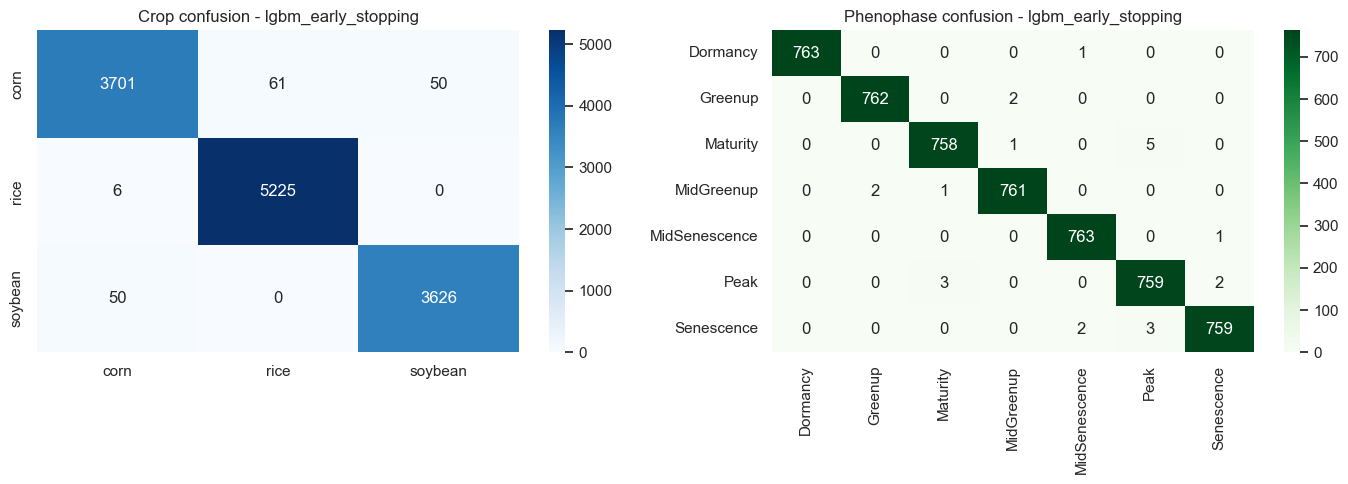

,precision,recall,f1-score,support
corn,0.9851,0.9709,0.9779,3812.0000
rice,0.9885,0.9989,0.9936,5231.0000
soybean,0.9864,0.9864,0.9864,3676.0000
accuracy,0.9869,0.9869,0.9869,0.9869
macro avg,0.9867,0.9854,0.9860,12719.0000
weighted avg,0.9869,0.9869,0.9868,12719.0000


,precision,recall,f1-score,support
Dormancy,1.0000,0.9987,0.9993,764.0000
Greenup,0.9974,0.9974,0.9974,764.0000
Maturity,0.9948,0.9921,0.9934,764.0000
MidGreenup,0.9961,0.9961,0.9961,764.0000
MidSenescence,0.9961,0.9987,0.9974,764.0000
Peak,0.9896,0.9935,0.9915,764.0000
Senescence,0.9961,0.9935,0.9948,764.0000
accuracy,0.9957,0.9957,0.9957,0.9957
macro avg,0.9957,0.9957,0.9957,5348.0000
weighted avg,0.9957,0.9957,0.9957,5348.0000


In [12]:
# Visual report for the selected models.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(crop_score["confusion"], annot=True, fmt="d", cmap="Blues", ax=axes[0])
axes[0].set_title(f"Crop confusion - {crop_model_name}")
sns.heatmap(phase_score["confusion"], annot=True, fmt="d", cmap="Greens", ax=axes[1])
axes[1].set_title(f"Phenophase confusion - {phase_model_name}")
plt.tight_layout()
plt.show()

display(pd.DataFrame(crop_score["report"]).T.round(4))
display(pd.DataFrame(phase_score["report"]).T.round(4))